In [1]:
import os
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("train.csv", index_col=0)
data = data.reset_index()
data.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} columns")


The dataset has 913000 rows and 4 columns


In [4]:
# Create initial DataFrame
df = pd.DataFrame(data)

# Convert date to datetime format
df['date'] = pd.to_datetime(df['date'])

# Step 1: Create store-item combinations (format: "store_item" → "1_28")
df['store_item'] = df['store'].astype(str) + '_' + df['item'].astype(str)

# Step 2: Group by date and store_item
item_sales_per_date = df.groupby(['date', 'store_item'])['sales'].sum().reset_index()

# Step 3: Create complete date-store_item grid
all_dates = pd.date_range(start=df['date'].min(), end=df['date'].max())
all_store_items = df['store_item'].unique()

# Create MultiIndex
multiindex = pd.MultiIndex.from_product(
    [all_dates, all_store_items],
    names=('date', 'store_item')
)

# Reindex to fill missing combinations
item_sales_per_date = (
    item_sales_per_date
    .set_index(['date', 'store_item'])
    .reindex(multiindex)
    .reset_index()
    .rename(columns={'level_0': 'date', 'level_1': 'store_item'})
)

# Fill missing sales with 0 instead of NaN
item_sales_per_date['sales'] = item_sales_per_date['sales'].fillna(0)

# Display the result (matches your example structure)
print(item_sales_per_date)

             date store_item  sales
0      2013-01-01        1_1     13
1      2013-01-01        2_1     12
2      2013-01-01        3_1     19
3      2013-01-01        4_1     10
4      2013-01-01        5_1     11
...           ...        ...    ...
912995 2017-12-31       6_50     45
912996 2017-12-31       7_50     46
912997 2017-12-31       8_50     76
912998 2017-12-31       9_50     65
912999 2017-12-31      10_50     82

[913000 rows x 3 columns]


In [5]:
import itertools
 
multiindex = list(zip(item_sales_per_date["date"], item_sales_per_date["store_item"]))
multiindex = pd.MultiIndex.from_tuples(multiindex, names=('index_1', 'index_2'))
 
dataset = item_sales_per_date.copy()
dataset.index = multiindex
 
 
idx_dates = list(pd.date_range(min(item_sales_per_date["date"]), max(item_sales_per_date["date"])))
idx_ids = list(dataset["store_item"].unique())
idx = list(itertools.product(idx_dates, idx_ids))
dataset = dataset.reindex(idx)
dataset = dataset.reset_index()
dataset.head()

,index_1,index_2,date,store_item,sales
0,2013-01-01,1_1,2013-01-01,1_1,13
1,2013-01-01,2_1,2013-01-01,2_1,12
2,2013-01-01,3_1,2013-01-01,3_1,19
3,2013-01-01,4_1,2013-01-01,4_1,10
4,2013-01-01,5_1,2013-01-01,5_1,11


In [6]:
dataset["date"] = dataset["date"].fillna(dataset["index_1"])
dataset["store_item"] = dataset["store_item"].fillna(dataset["index_2"])
dataset["sales"] = dataset["sales"].fillna(0)
dataset = dataset.drop(columns=["index_1", "index_2"])
dataset = dataset.set_index("date")
dataset.index.name = "date"
dataset.head()

,store_item,sales
date,,
2013-01-01,1_1,13
2013-01-01,2_1,12
2013-01-01,3_1,19
2013-01-01,4_1,10
2013-01-01,5_1,11


In [7]:
# Save DataFrame to CSV
dataset.to_csv('sales_data.csv', index=False)

In [8]:
Y_df = dataset.copy()
Y_df = Y_df.reset_index()
Y_df = Y_df.rename(columns={
    'store_item': 'unique_id', 
    'date': 'ds', 
    'sales': 'y'
})
Y_df['y'] = Y_df['y'].astype(int)
# Convert the 'ds' column to datetime format to ensure proper handling of date-related operations in subsequent steps
Y_df['ds'] = pd.to_datetime(Y_df['ds'])
 
 
Y_df['unique_id'] = Y_df['unique_id'].astype(str)
 
Y_df.tail()


,ds,unique_id,y
912995,2017-12-31,6_50,45
912996,2017-12-31,7_50,46
912997,2017-12-31,8_50,76
912998,2017-12-31,9_50,65
912999,2017-12-31,10_50,82


In [9]:
# Import Prophet
from prophet import Prophet
## Creating model parameters
model_param ={
    "daily_seasonality": False,
    "weekly_seasonality":False,
    "yearly_seasonality":True,
    "seasonality_mode": "multiplicative",
    "growth": "logistic"
}
Y_df['cap']= Y_df["y"].max() + Y_df["y"].std() * 0.05
# Setting a cap or upper limit for the forecast as we are using logistics growth
# The cap will be maximum value of target variable plus 5% of std.
model = Prophet(**model_param)
model.fit(Y_df)
 
# Create future dataframe
future= model.make_future_dataframe(periods=365)
future['cap'] = Y_df['cap'].max()
 
forecast= model.predict(future)

Importing plotly failed. Interactive plots will not work.
20:43:19 - cmdstanpy - INFO - Chain [1] start processing
20:46:01 - cmdstanpy - INFO - Chain [1] done processing


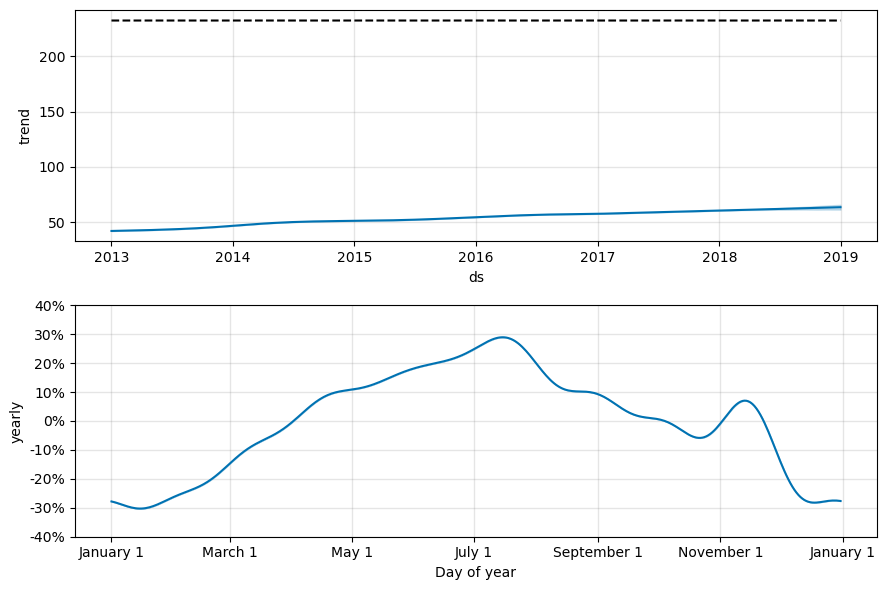

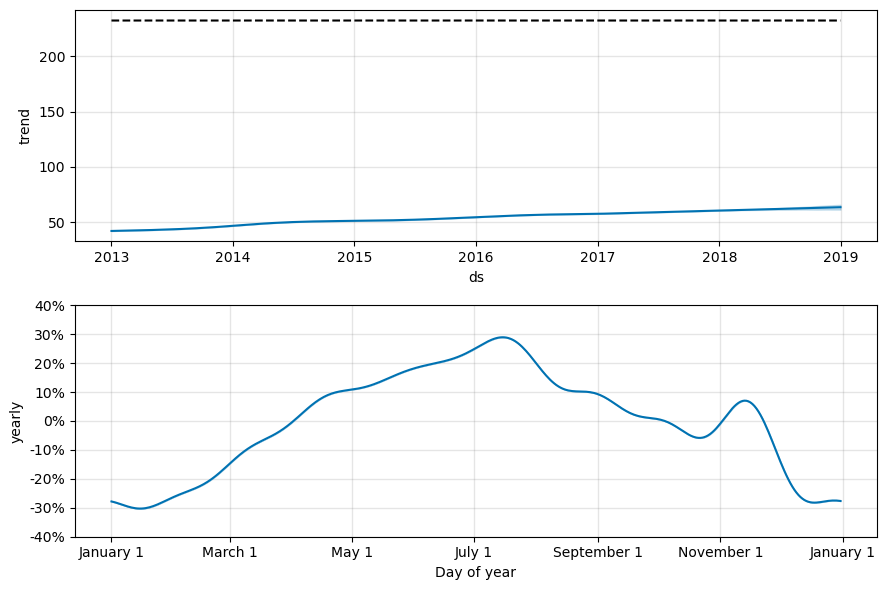

In [10]:
	
model.plot_components(forecast)

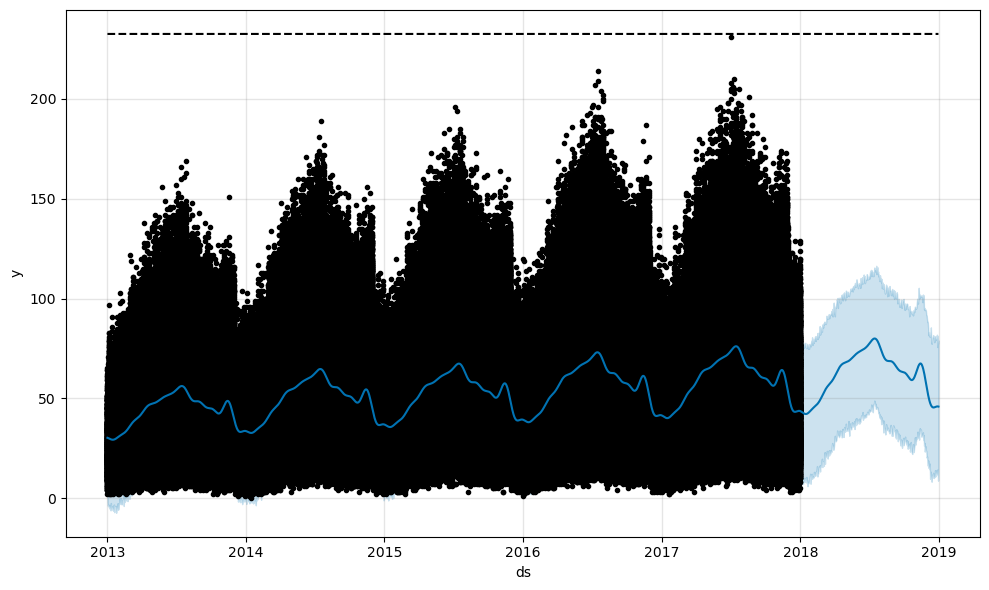

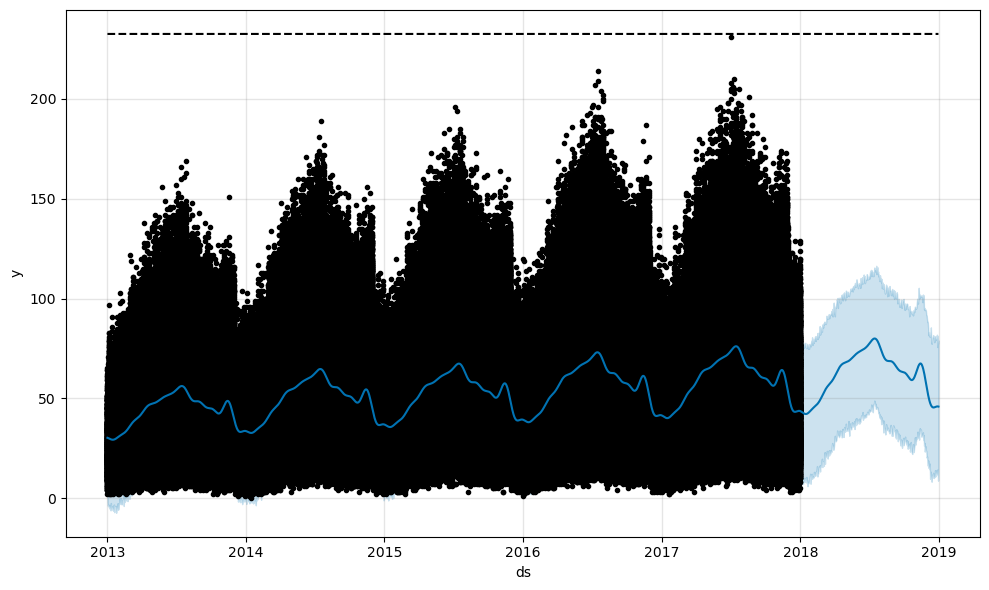

In [11]:
	
model.plot(forecast)

In [12]:
## Adding parameters and seasonality and events
model = Prophet(**model_param)
 
model= model.add_seasonality(name="monthly", period=30, fourier_order=10)
model= model.add_seasonality(name="quarterly", period=92.25, fourier_order=10)
 
model.add_country_holidays("US")
 
model.fit(Y_df)
 
# Create future dataframe
future= model.make_future_dataframe(periods=365)
future['cap'] = Y_df['cap'].max()
 
forecast= model.predict(future)

20:52:31 - cmdstanpy - INFO - Chain [1] start processing
21:05:25 - cmdstanpy - INFO - Chain [1] done processing


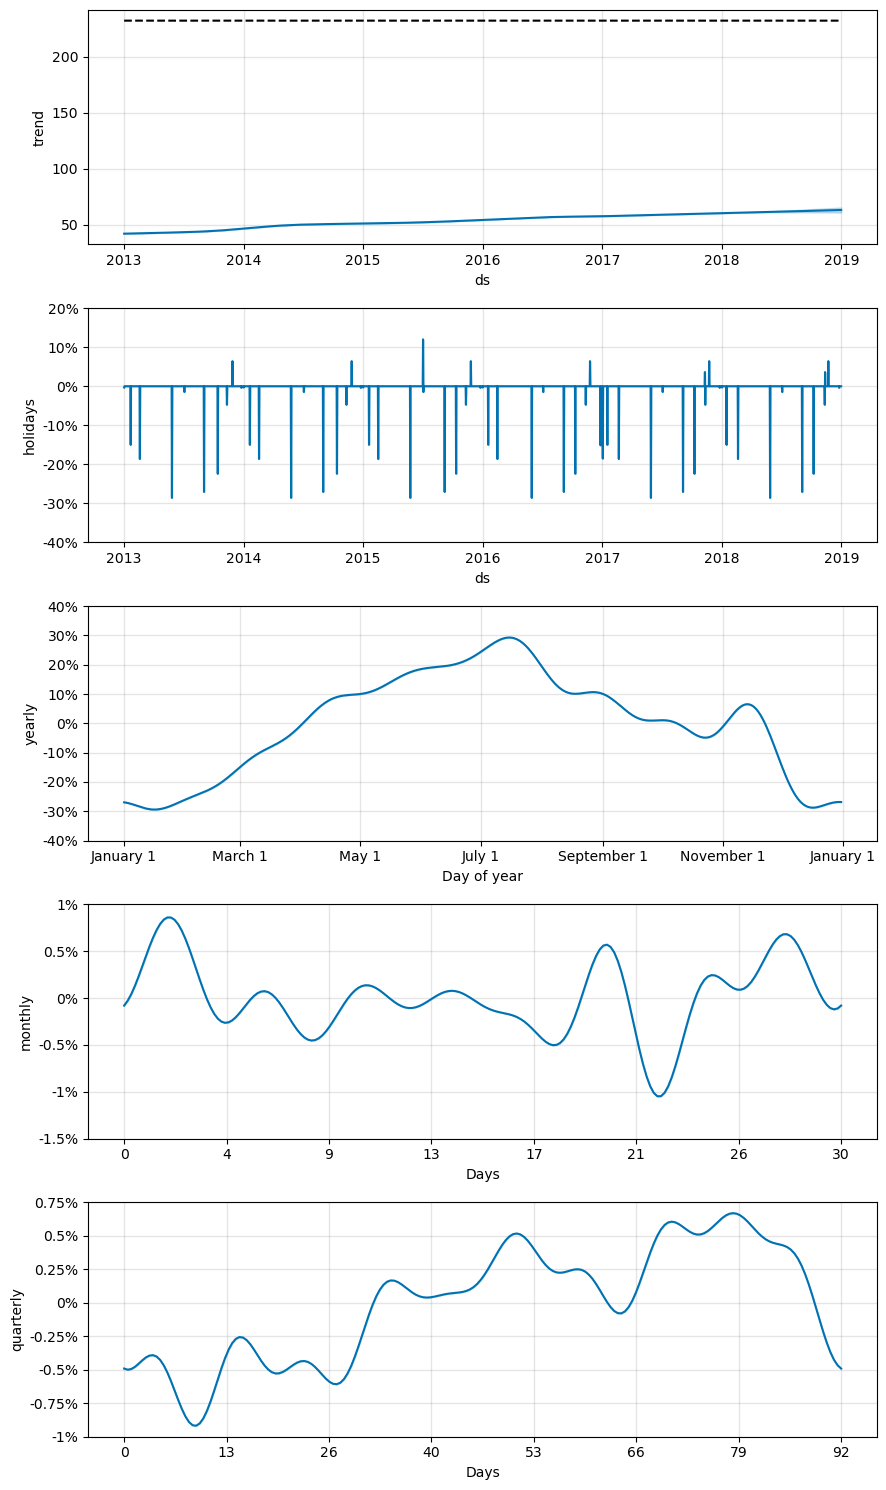

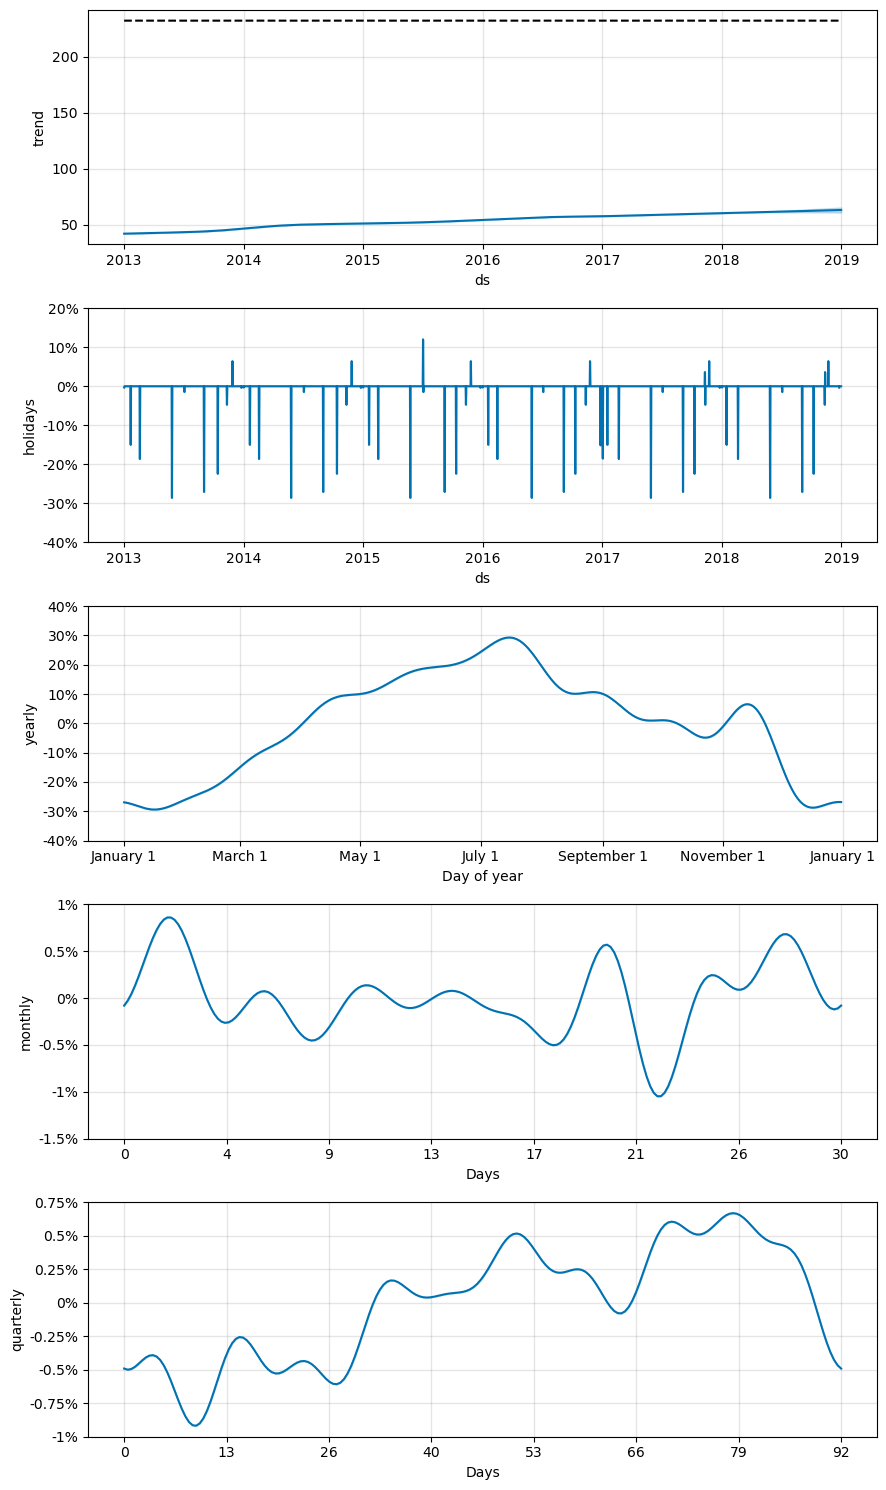

In [13]:
	
model.plot_components(forecast)


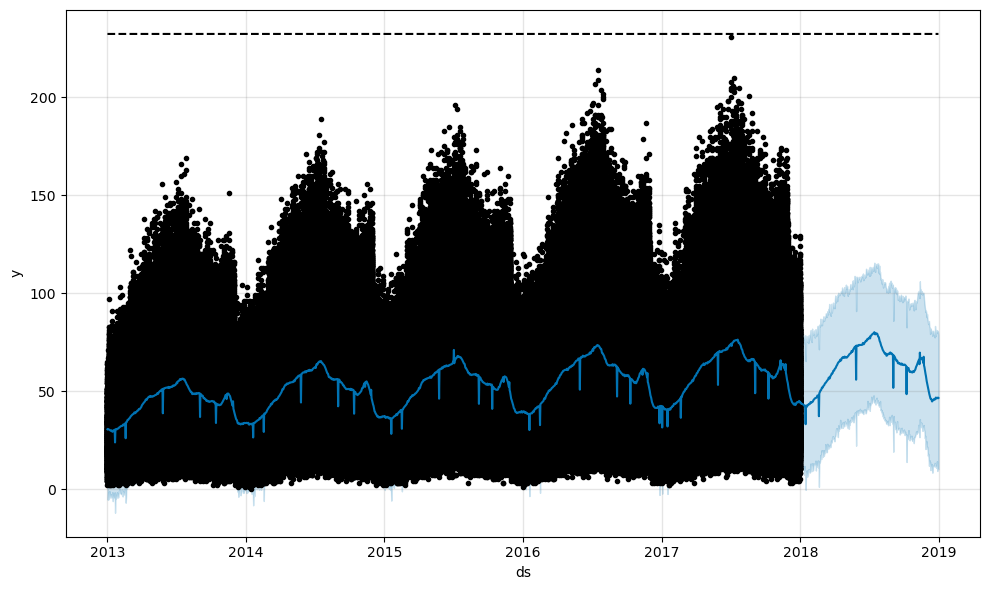

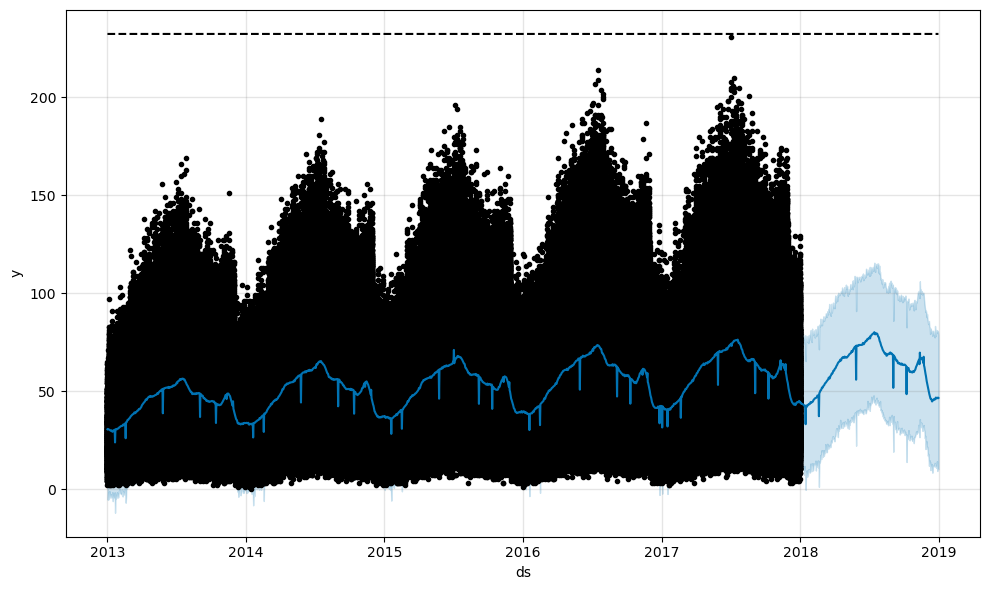

In [14]:
	
model.plot(forecast)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from prophet import Prophet
 
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)
df_store_2_item_28 = pd.read_csv("sales_store_2_item_28.csv")

<Figure size 1500x600 with 0 Axes>

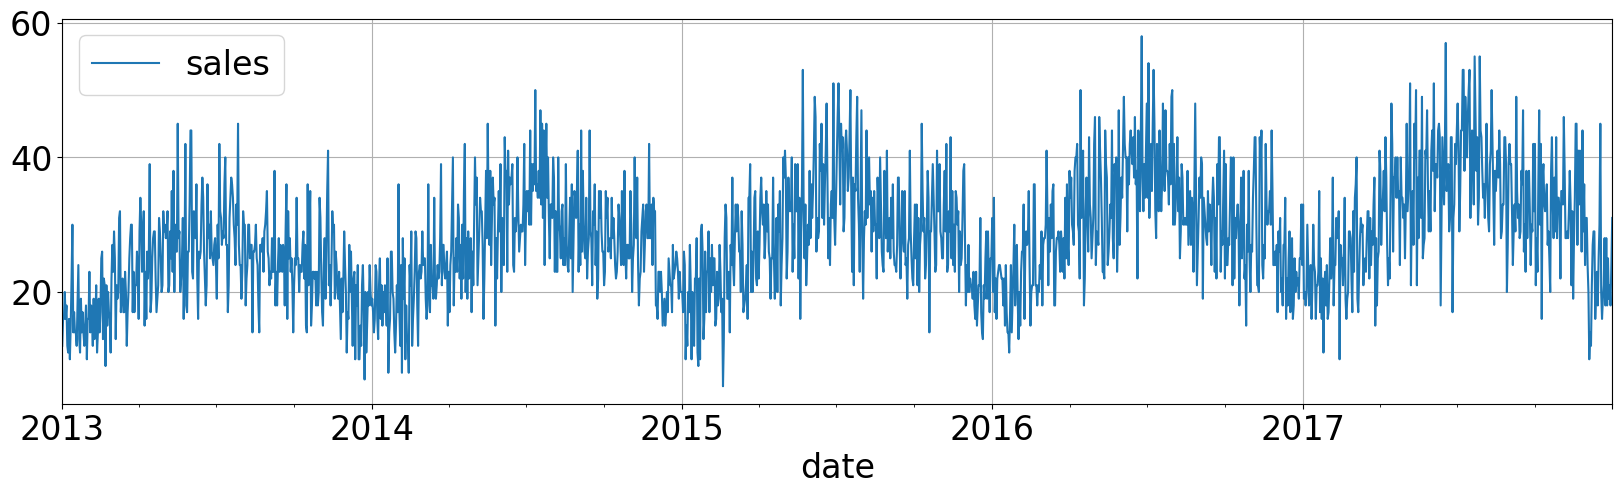

In [16]:
import matplotlib
plt.figure(figsize=(15, 6))
matplotlib.rcParams.update({'font.size': 24})
df_store_2_item_28['date']=pd.to_datetime(df_store_2_item_28['date'])
df_store_2_item_28_time = df_store_2_item_28.set_index('date')
# Plot the entire time series data
df_store_2_item_28_time.plot(grid=True,figsize=(20,5))
plt.show()

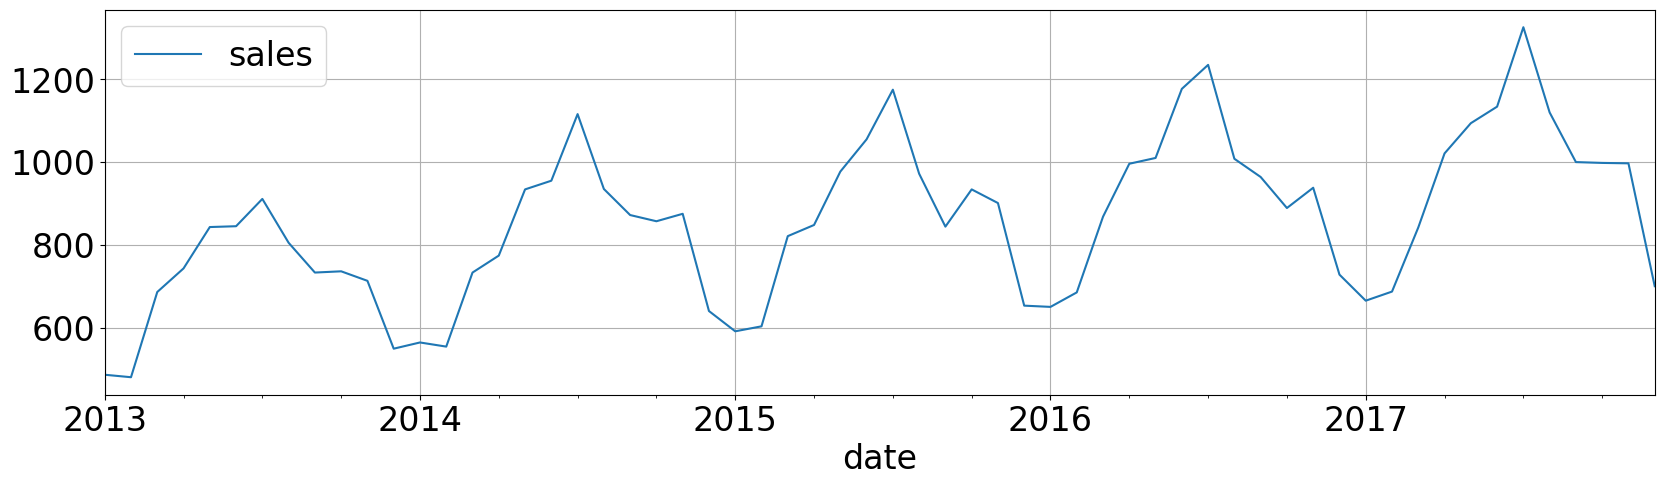

In [17]:
df_store_2_item_28_time.resample('M').sum().plot(grid=True,figsize=(20,5))
plt.show()


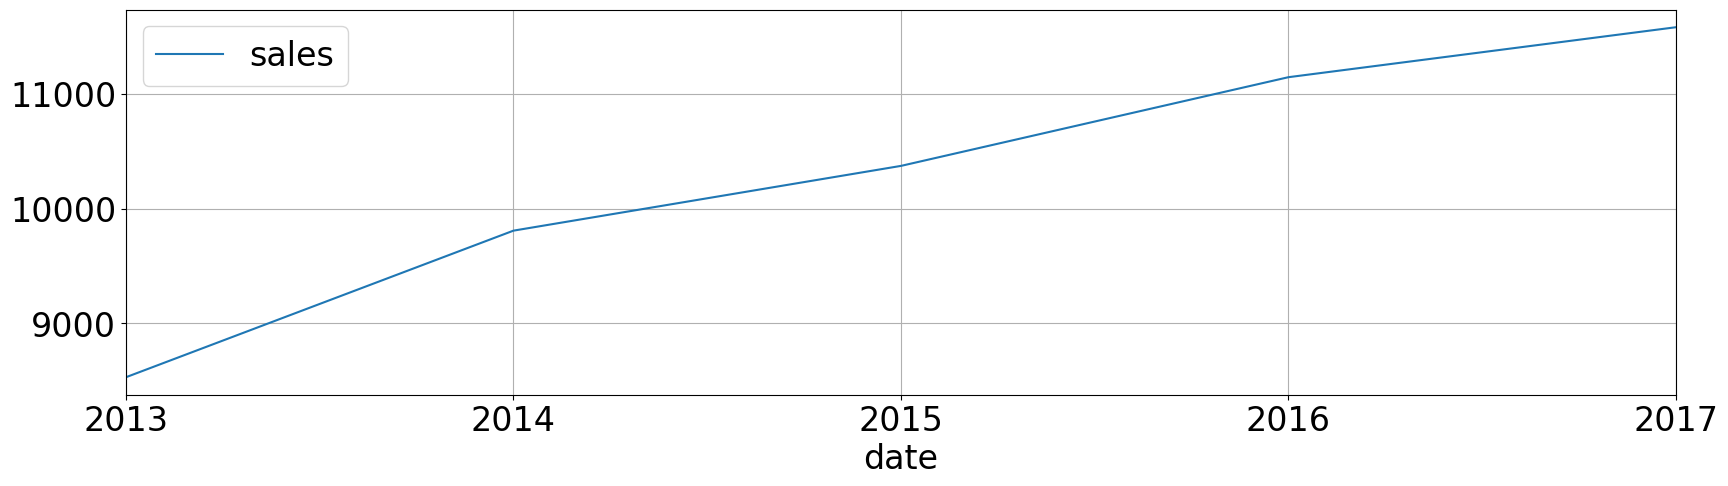

In [18]:
df_store_2_item_28_time.resample('A').sum().plot(grid=True,figsize=(20,5))
plt.show()

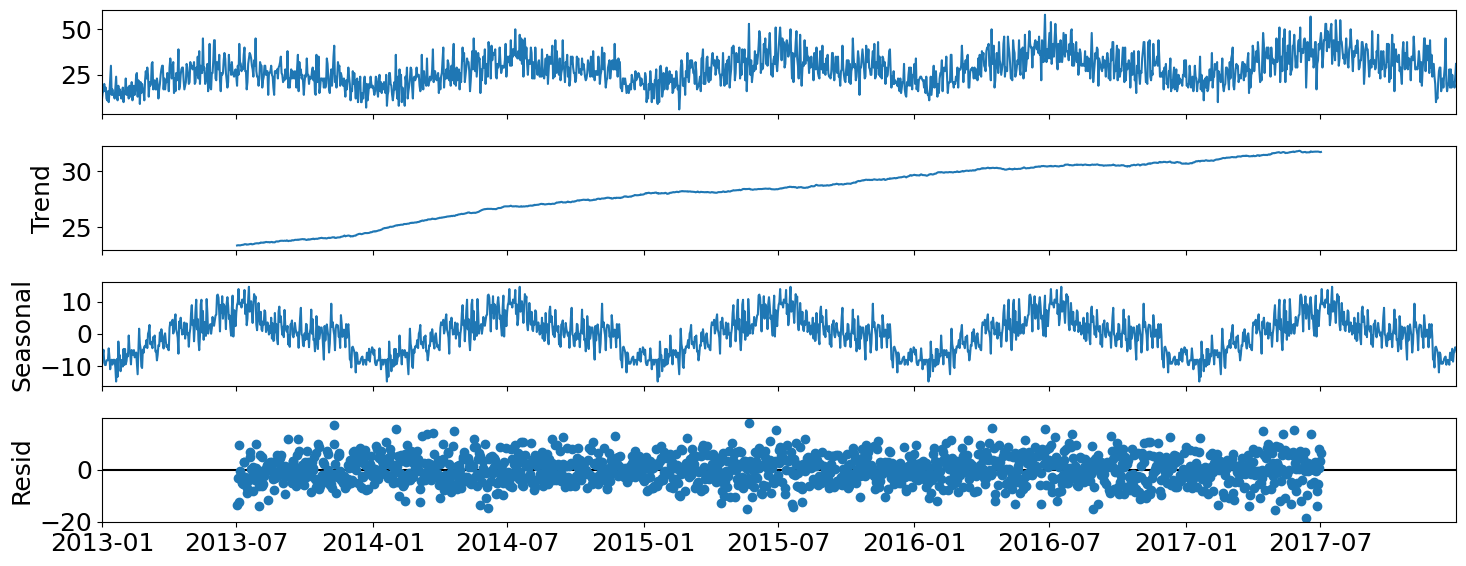

In [19]:
from pylab import rcParams
matplotlib.rcParams.update({'font.size': 18})
rcParams['figure.figsize'] = 15, 6
decomposition = sm.tsa.seasonal_decompose(df_store_2_item_28_time, 
                                         model = 'additive',
                                         period=365) 
fig = decomposition.plot()
plt.show()

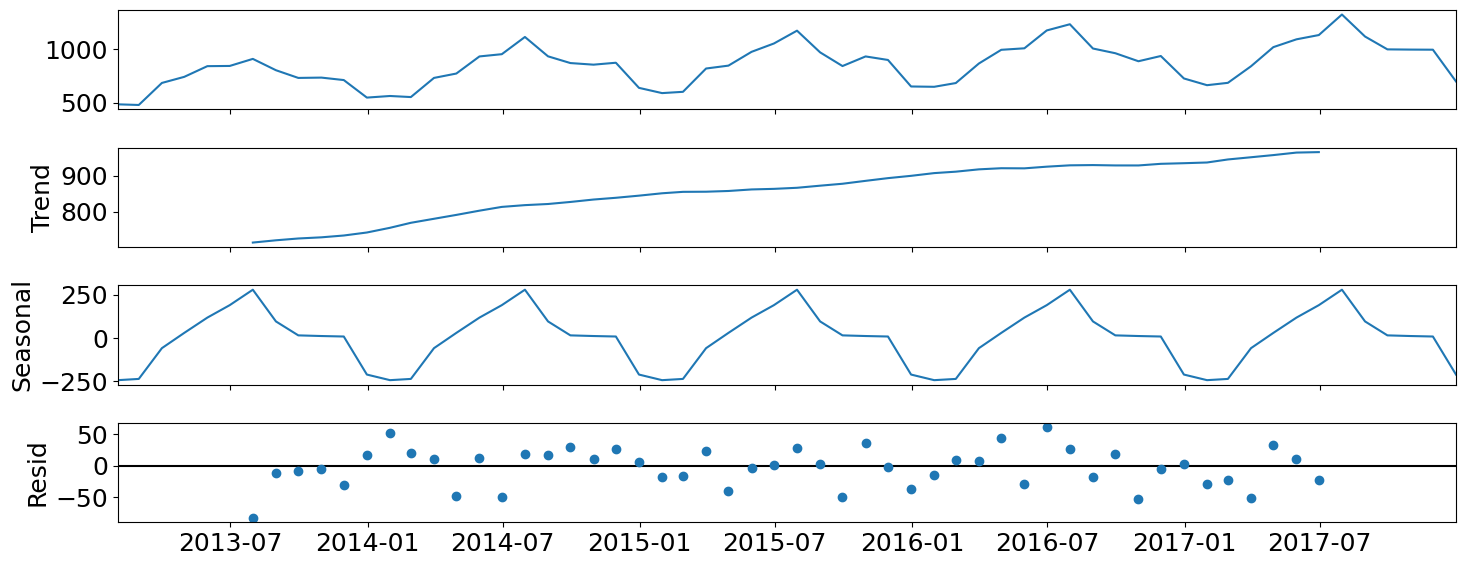

In [20]:
decomposition = sm.tsa.seasonal_decompose(df_store_2_item_28_time.resample('M').sum(), 
                                          model = 'additive',
                                         period=12) 
fig = decomposition.plot()
plt.show()

21:18:55 - cmdstanpy - INFO - Chain [1] start processing
21:18:55 - cmdstanpy - INFO - Chain [1] done processing


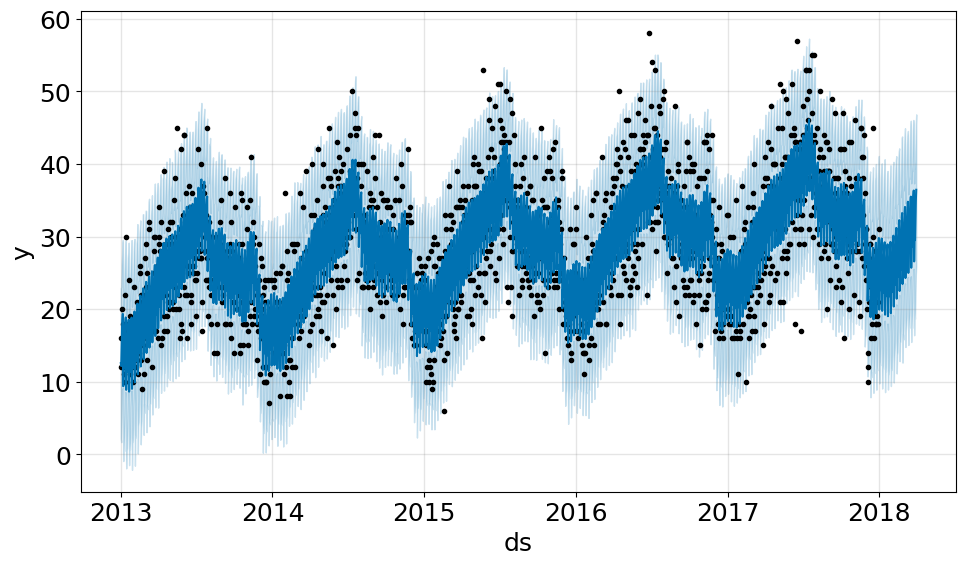

In [21]:
# rename date and sales, respectively ds and y
df_store_2_item_28.columns = ['ds','y']
m = Prophet(interval_width=0.95) #by default is 80%
model = m.fit(df_store_2_item_28)
future = m.make_future_dataframe(periods=90) 
forecast = m.predict(future)
plot1 = m.plot(forecast)

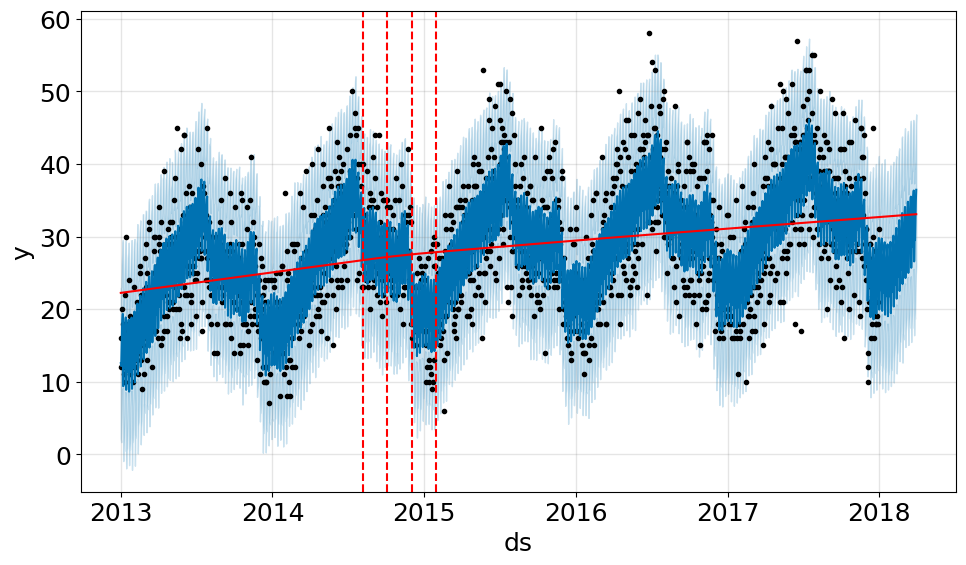

In [22]:
from prophet.plot import add_changepoints_to_plot
 
plot1 = m.plot(forecast)
a = add_changepoints_to_plot(plot1.gca(),m,forecast)

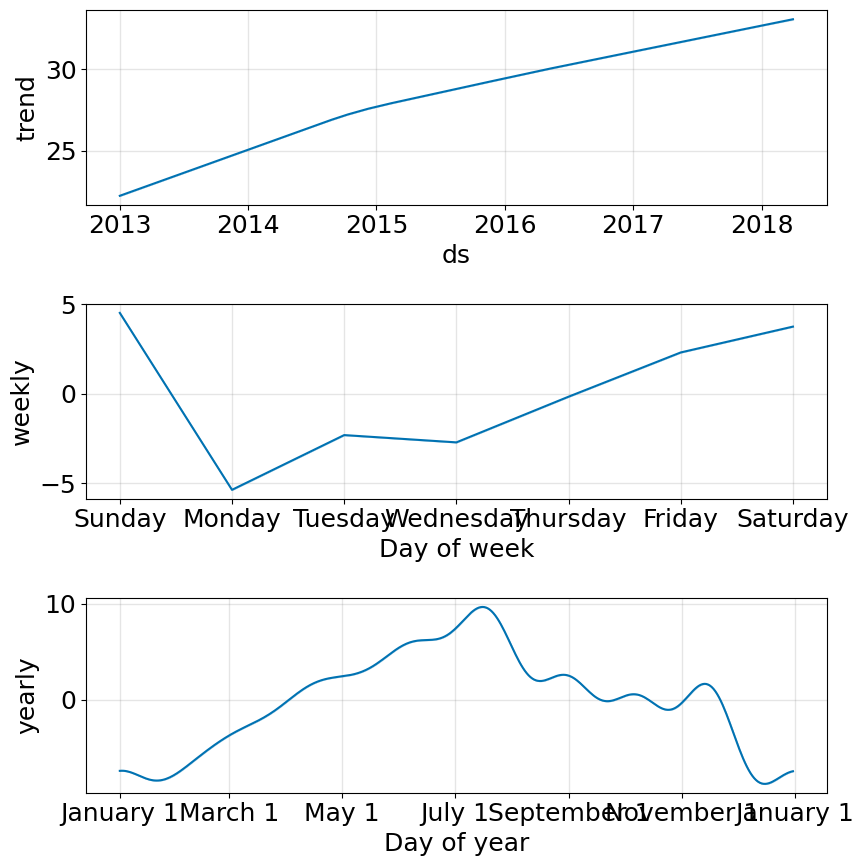

In [23]:
plot2 = m.plot_components(forecast)

MAE: 4.275


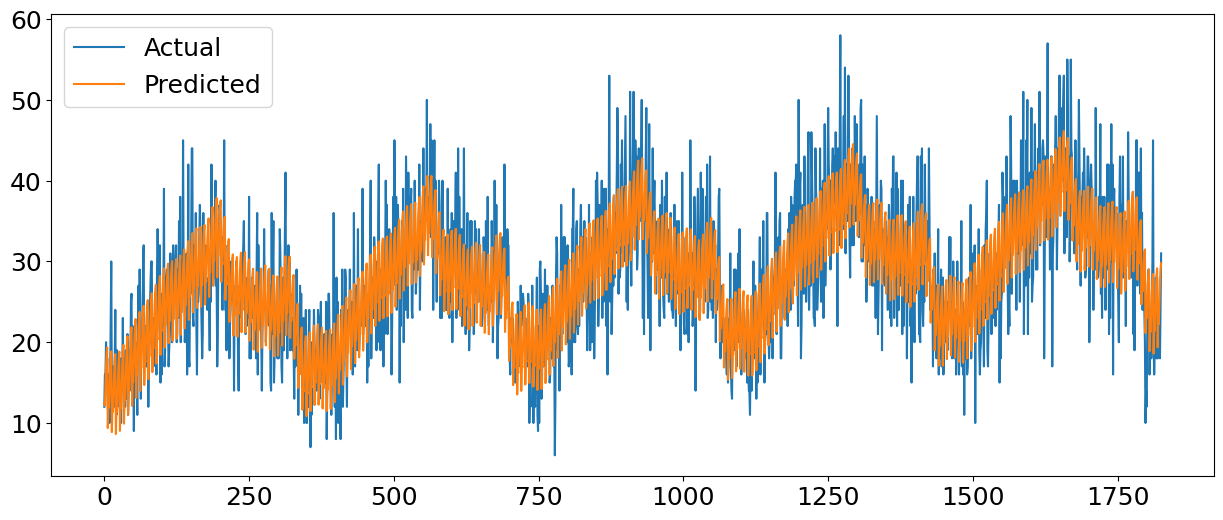

In [24]:
df_merge = pd.merge(df_store_2_item_28, forecast[['ds','yhat_lower','yhat_upper','yhat']],on='ds')
df_merge = df_merge[['ds','yhat_lower','yhat_upper','yhat','y']]
# calculate MAE between observed and predicted values 
y_true = df_merge['y'].values
y_pred = df_merge['yhat'].values
mae_01 = mean_absolute_error(y_true, y_pred)
print('MAE: %.3f' % mae_01)
MAE: 4.275
# plot expected vs actual
plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()

In [25]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(m, horizon='90 days')



  0%|          | 0/31 [00:00<?, ?it/s]

21:18:59 - cmdstanpy - INFO - Chain [1] start processing
21:18:59 - cmdstanpy - INFO - Chain [1] done processing
21:19:00 - cmdstanpy - INFO - Chain [1] start processing
21:19:00 - cmdstanpy - INFO - Chain [1] done processing
21:19:00 - cmdstanpy - INFO - Chain [1] start processing
21:19:00 - cmdstanpy - INFO - Chain [1] done processing
21:19:01 - cmdstanpy - INFO - Chain [1] start processing
21:19:01 - cmdstanpy - INFO - Chain [1] done processing
21:19:01 - cmdstanpy - INFO - Chain [1] start processing
21:19:01 - cmdstanpy - INFO - Chain [1] done processing
21:19:01 - cmdstanpy - INFO - Chain [1] start processing
21:19:02 - cmdstanpy - INFO - Chain [1] done processing
21:19:02 - cmdstanpy - INFO - Chain [1] start processing
21:19:02 - cmdstanpy - INFO - Chain [1] done processing
21:19:02 - cmdstanpy - INFO - Chain [1] start processing
21:19:02 - cmdstanpy - INFO - Chain [1] done processing
21:19:03 - cmdstanpy - INFO - Chain [1] start processing
21:19:03 - cmdstanpy - INFO - Chain [1]

In [26]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)

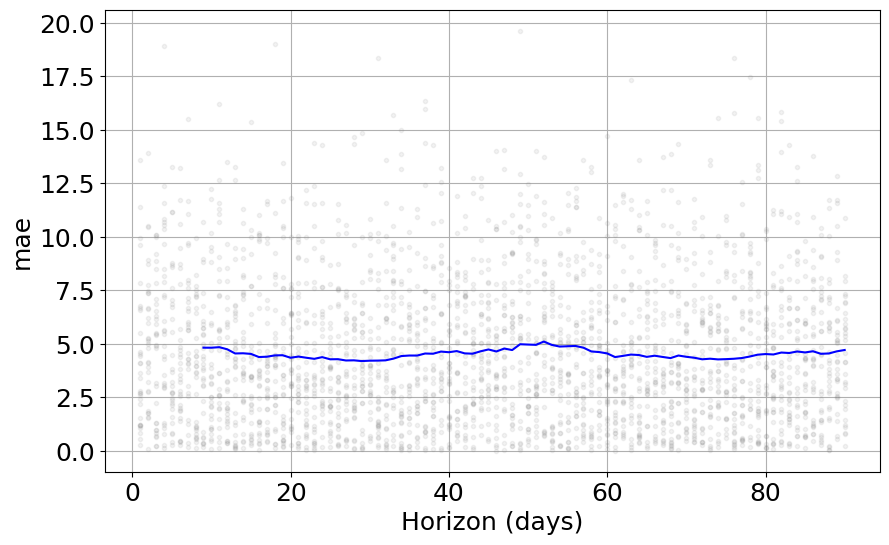

In [27]:
from prophet.plot import plot_cross_validation_metric
 
plot3 = plot_cross_validation_metric(df_cv, metric='mae')


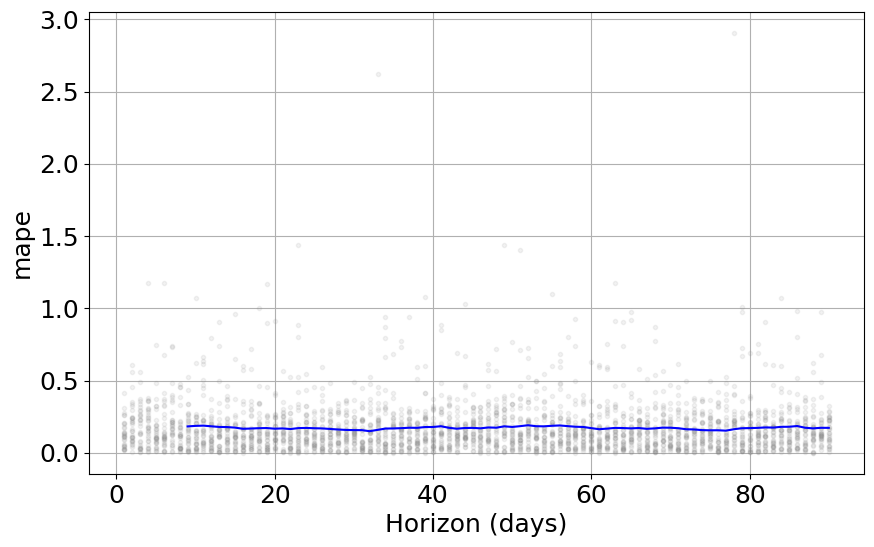

In [28]:
plot4 = plot_cross_validation_metric(df_cv, metric='mape')

In [29]:
y_true = df_merge['y'].values
y_pred = df_merge['yhat'].values
mae_01 = mean_absolute_error(y_true, y_pred)
print('MAE: %.3f' % mae_01)
MAE: 4.252
mape_01 = mean_absolute_percentage_error(y_true, y_pred)
print('MAPE: %.3f' % mape_01)
MAPE: 0.168
metrics_prophet_01 = [round(mae_01,3), 
                 round(mape_01,3)]

MAE: 4.275
MAPE: 0.169


In [30]:
import itertools
 
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],   
}
 
# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
maes = []  # Store the MAE for each params here
mapes = [] # Store the MAPE for each params here
 
# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params).fit(df_store_2_item_28)  # Fit model with given params
    df_cv = cross_validation(m, horizon='90 days', parallel="processes")
    df_p = performance_metrics(df_cv, rolling_window=1)
    maes.append(df_p['mae'].values[0])
    mapes.append(df_p['mape'].values[0])
 
# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['mae'] = maes
tuning_results['mape'] = mapes
tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df.sort_values(['mae','mape'])

21:36:47 - cmdstanpy - INFO - Chain [1] start processing
21:36:48 - cmdstanpy - INFO - Chain [1] done processing
21:37:13 - cmdstanpy - INFO - Chain [1] start processing
21:37:13 - cmdstanpy - INFO - Chain [1] done processing
21:37:35 - cmdstanpy - INFO - Chain [1] start processing
21:37:36 - cmdstanpy - INFO - Chain [1] done processing
21:37:54 - cmdstanpy - INFO - Chain [1] start processing
21:37:55 - cmdstanpy - INFO - Chain [1] done processing
21:38:09 - cmdstanpy - INFO - Chain [1] start processing
21:38:10 - cmdstanpy - INFO - Chain [1] done processing
21:38:21 - cmdstanpy - INFO - Chain [1] start processing
21:38:21 - cmdstanpy - INFO - Chain [1] done processing
21:38:33 - cmdstanpy - INFO - Chain [1] start processing
21:38:33 - cmdstanpy - INFO - Chain [1] done processing
21:38:45 - cmdstanpy - INFO - Chain [1] start processing
21:38:45 - cmdstanpy - INFO - Chain [1] done processing
21:38:58 - cmdstanpy - INFO - Chain [1] start processing
21:38:58 - cmdstanpy - INFO - Chain [1]

,changepoint_prior_scale,seasonality_prior_scale,mae,mape
7,0.010,10.00,4.562249,0.174862
6,0.010,1.00,4.562324,0.174897
10,0.100,1.00,4.568360,0.171526
11,0.100,10.00,4.570073,0.171523
5,0.010,0.10,4.574094,0.175388
9,0.100,0.10,4.575828,0.171807
15,0.500,10.00,4.660557,0.173754
14,0.500,1.00,4.663988,0.173913
13,0.500,0.10,4.678431,0.174140
2,0.001,1.00,4.761234,0.187183


In [31]:
best_params = all_params[np.argmin(mapes)]
print(best_params)
{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}
m = Prophet(interval_width=0.95, weekly_seasonality=True, 
            changepoint_prior_scale=best_params['changepoint_prior_scale'], 
            seasonality_prior_scale=best_params['seasonality_prior_scale'])
model = m.fit(df_store_2_item_28)
future = m.make_future_dataframe(periods=90) #to predict 90 days in the future
forecast = m.predict(future)

{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}


22:08:08 - cmdstanpy - INFO - Chain [1] start processing
22:08:09 - cmdstanpy - INFO - Chain [1] done processing


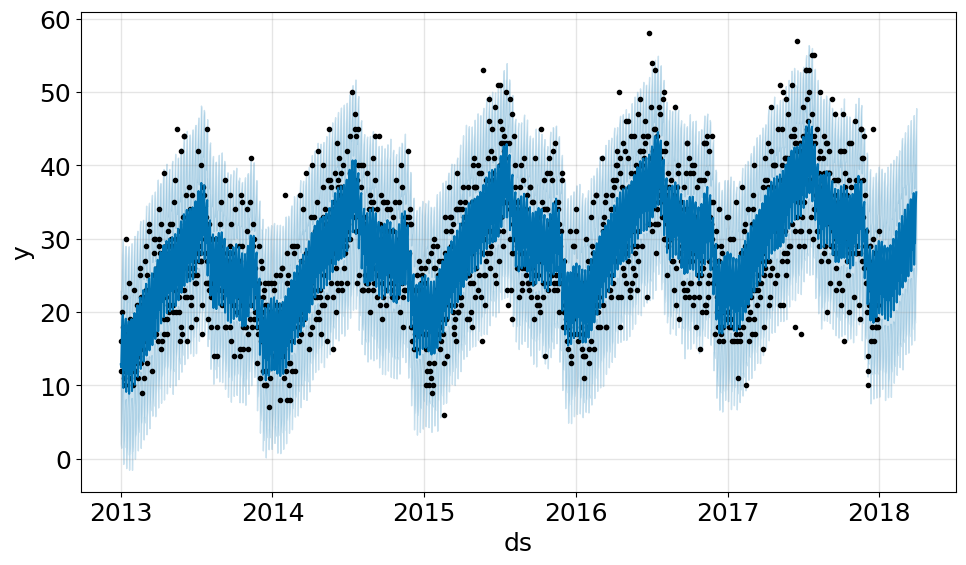

In [32]:
	
plot5 = m.plot(forecast)